In [1]:
import numpy as np
import pandas as pd

from pyBKT.models import *
from pyBKT.models import Model
from matplotlib import pyplot as plt
from bkt_preprocessing import extract_mc


model = Model(seed=52, num_fits=10)
model.load(loc='without_forget.pkl')

In [2]:
ratings = pd.read_csv('../data/ml-1m/ratings.csv')
_, df = extract_mc(num_topics=20, rating_data=ratings, ratio=0.2, flag=False)

params = model.params().reset_index()

In [9]:
df[(df['userId'] == 1679) & (df['mc'] == '11')]

,userId,movieId,rating,timestamp,mc
472213,1679,2951,1,974708508,11
472224,1679,2683,1,974708754,11
472282,1679,2761,1,974709360,11
472292,1679,3623,1,974709464,11
472301,1679,2093,1,974709715,11
472303,1679,2394,1,974709715,11
472308,1679,2598,1,974709715,11
472340,1679,3624,1,974709981,11
472343,1679,3555,1,974710066,11
472352,1679,2791,0,974710276,11


In [3]:
def compute_posterior(prior, response, learn, guess, slip, forget):
    if response:
        correct = prior * (1 - slip) + (1 - prior) * guess
        observed_mastery = (prior * (1 - slip)) / (correct + 1e-1000)

    else:
        incorrect = prior * slip + (1 - prior) * (1 - guess)
        observed_mastery = (prior * slip) / (incorrect + 1e-1000)
    
    updated_mastery = observed_mastery * (1 - forget) + (1 - observed_mastery) * learn

    return updated_mastery


def update_pf_state(user_id, target_mc):
    history = df[(df['userId'] == user_id) & (df['mc'].isin(['17', '7', '11', '0', '15']))]
    history = history.reset_index(drop=True)

    mastery_prob = []
    init_mastery_prob = params[(params['skill'] == target_mc) & (params['param'] == 'prior')]['value'].values[0]
    mastery_prob.append(init_mastery_prob)

    responses = list(history[history['mc'] == target_mc]['rating'].values)
    movie_ids = list(history[history['mc'] == target_mc]['movieId'].values)

    for response, movie_id in zip(responses, movie_ids):
        mastery_prob.append(
            compute_posterior(
                prior=mastery_prob[-1], 
                response=response, 
                learn=params[(params['skill'] == target_mc) & (params['param'] == 'learns')]['value'].values[0], 
                guess=params[(params['skill'] == target_mc) & (params['param'] == 'guesses') & (params['class'] == str(movie_id))]['value'].values[0], 
                slip=params[(params['skill'] == target_mc) & (params['param'] == 'slips') & (params['class'] == str(movie_id))]['value'].values[0], 
                forget=0
            )
        )

    return mastery_prob

In [4]:
mastery_prob_17 = update_pf_state(user_id=1679, target_mc='17')
mastery_prob_7 = update_pf_state(user_id=1679, target_mc='7')
mastery_prob_11 = update_pf_state(user_id=1679, target_mc='11')
mastery_prob_0 = update_pf_state(user_id=1679, target_mc='0')
mastery_prob_15 = update_pf_state(user_id=1679, target_mc='15')

In [5]:
row_1 = [mastery_prob_17[0]] * 2 + [mastery_prob_17[1]] * 3 + [mastery_prob_17[2]] * 3 + [mastery_prob_17[3]] + [mastery_prob_17[4]] + [mastery_prob_17[5]] * 7 + [mastery_prob_17[6]] + [mastery_prob_17[7]] * 2 + [mastery_prob_17[8]] * 4
row_2 = [mastery_prob_7[0]] * 4 + [mastery_prob_7[1]] * 2 + [mastery_prob_7[2]] + [mastery_prob_7[3]] * 6 + [mastery_prob_7[4]] * 10 + [mastery_prob_7[5]]
row_3 = [mastery_prob_11[0]] + [mastery_prob_11[1]] * 2 + [mastery_prob_11[2]] * 8 + [mastery_prob_11[3]] + [mastery_prob_11[4]] * 2 + [mastery_prob_11[5]] + [mastery_prob_11[6]] + [mastery_prob_11[7]] * 5 + [mastery_prob_11[8]] + [mastery_prob_11[9]] * 2
row_4 = [mastery_prob_0[0]] * 24
row_5 = [mastery_prob_15[0]] * 19 + [mastery_prob_15[1]] * 5

assert(len(row_1) == 24)
assert(len(row_2) == 24)
assert(len(row_3) == 24)
assert(len(row_4) == 24)
assert(len(row_5) == 24)

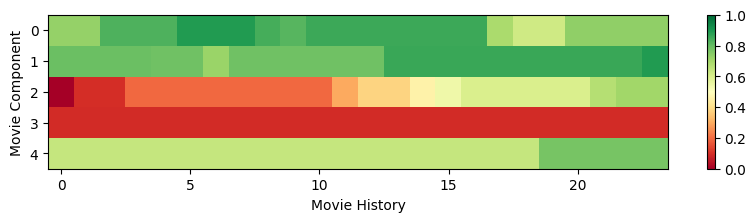

In [6]:
hmap_data = np.array([row_1, row_2, row_3, row_4, row_5])
fig, ax = plt.subplots(figsize=(10, 2))
cmap = plt.get_cmap('RdYlGn')
cax = ax.imshow(hmap_data, aspect='auto', cmap=cmap, vmin=0, vmax=1)
cbar = fig.colorbar(cax, ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.xlabel('Movie History')
plt.ylabel('Movie Component')
plt.show()